# Multi-Model LLM Inference Benchmark Analysis

This notebook analyzes and compares the inference performance of three open-weight instruction-tuned language models evaluated on an NVIDIA RTX A6000 GPU:

- Qwen/Qwen2.5-7B-Instruct
- microsoft/Phi-4-mini-instruct
- mistralai/Mistral-7B-Instruct-v0.3

## Evaluation Metrics

The comparison focuses on:

- Generation latency
- Token throughput
- Peak GPU memory allocation
- Peak GPU memory reservation
- Model loading time
- Performance across benchmark prompts

All models were evaluated using the same configuration-driven benchmark framework and the same prompt suite.

In [5]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [7]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")
RESULTS_DIR = PROJECT_ROOT / "results"

RESULT_FILES = {
    "Qwen2.5-7B": RESULTS_DIR / "qwen25_7b_bf16.json",
    "Phi-4-mini": RESULTS_DIR / "phi4_mini_bf16.json",
    "Mistral-7B-v0.3": RESULTS_DIR / "mistral7b_v03_bf16.json",
}

results = {}

for label, path in RESULT_FILES.items():
    with path.open("r", encoding="utf-8") as file:
        results[label] = json.load(file)

print("Loaded benchmark results:")
for label in results:
    print(f"  - {label}")

Loaded benchmark results:
  - Qwen2.5-7B
  - Phi-4-mini
  - Mistral-7B-v0.3


In [8]:
rows = []

for label, data in results.items():
    peak_allocated = max(
        prompt["peak_vram_allocated_gb"]
        for prompt in data["prompts"]
    )

    peak_reserved = max(
        prompt["peak_vram_reserved_gb"]
        for prompt in data["prompts"]
    )

    rows.append(
        {
            "Model": label,
            "Model Name": data["model"]["name"],
            "Load Time (s)": data["model"]["load_seconds"],
            "Mean Generation Time (s)": data["summary"][
                "mean_generation_seconds"
            ],
            "Mean Throughput (tokens/s)": data["summary"][
                "mean_tokens_per_second"
            ],
            "Peak VRAM Allocated (GB)": peak_allocated,
            "Peak VRAM Reserved (GB)": peak_reserved,
        }
    )

comparison_df = pd.DataFrame(rows)

comparison_df.round(3)

,Model,Model Name,Load Time (s),Mean Generation Time (s),Mean Throughput (tokens/s),Peak VRAM Allocated (GB),Peak VRAM Reserved (GB)
0,Qwen2.5-7B,Qwen/Qwen2.5-7B-Instruct,44.977,7.412,34.538,14.211,14.229
1,Phi-4-mini,microsoft/Phi-4-mini-instruct,37.013,5.655,43.748,7.191,7.211
2,Mistral-7B-v0.3,mistralai/Mistral-7B-Instruct-v0.3,188.001,7.559,33.867,13.546,13.566


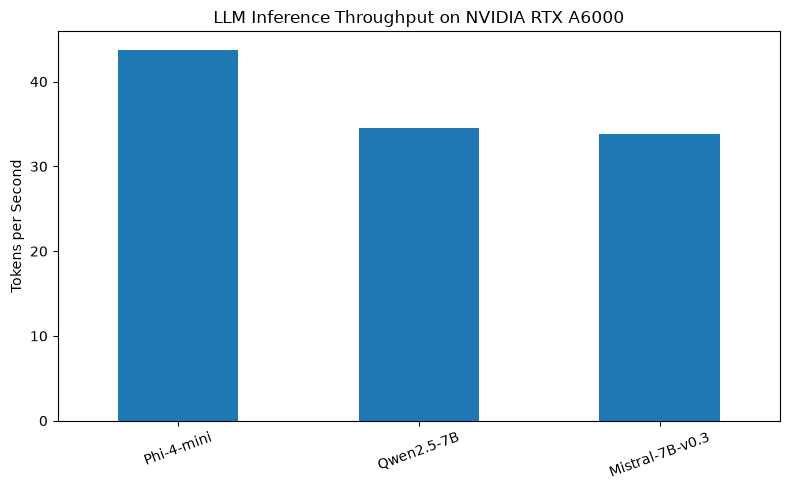

In [9]:
plot_df = comparison_df.sort_values(
    "Mean Throughput (tokens/s)",
    ascending=False,
)

ax = plot_df.plot(
    x="Model",
    y="Mean Throughput (tokens/s)",
    kind="bar",
    legend=False,
    figsize=(8, 5),
)

ax.set_title("LLM Inference Throughput on NVIDIA RTX A6000")
ax.set_ylabel("Tokens per Second")
ax.set_xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [10]:
qwen = comparison_df.loc[
    comparison_df["Model"] == "Qwen2.5-7B"
].iloc[0]

phi = comparison_df.loc[
    comparison_df["Model"] == "Phi-4-mini"
].iloc[0]

mistral = comparison_df.loc[
    comparison_df["Model"] == "Mistral-7B-v0.3"
].iloc[0]


def percent_improvement(new, baseline):
    return ((new - baseline) / baseline) * 100


phi_vs_qwen_throughput = percent_improvement(
    phi["Mean Throughput (tokens/s)"],
    qwen["Mean Throughput (tokens/s)"],
)

phi_vs_mistral_throughput = percent_improvement(
    phi["Mean Throughput (tokens/s)"],
    mistral["Mean Throughput (tokens/s)"],
)

phi_vs_qwen_vram_reduction = (
    1
    - phi["Peak VRAM Allocated (GB)"]
    / qwen["Peak VRAM Allocated (GB)"]
) * 100

phi_vs_mistral_vram_reduction = (
    1
    - phi["Peak VRAM Allocated (GB)"]
    / mistral["Peak VRAM Allocated (GB)"]
) * 100

print(
    "Phi-4-mini throughput improvement vs Qwen2.5-7B:",
    f"{phi_vs_qwen_throughput:.2f}%"
)

print(
    "Phi-4-mini throughput improvement vs Mistral-7B:",
    f"{phi_vs_mistral_throughput:.2f}%"
)

print(
    "Phi-4-mini VRAM reduction vs Qwen2.5-7B:",
    f"{phi_vs_qwen_vram_reduction:.2f}%"
)

print(
    "Phi-4-mini VRAM reduction vs Mistral-7B:",
    f"{phi_vs_mistral_vram_reduction:.2f}%"
)

Phi-4-mini throughput improvement vs Qwen2.5-7B: 26.66%
Phi-4-mini throughput improvement vs Mistral-7B: 29.18%
Phi-4-mini VRAM reduction vs Qwen2.5-7B: 49.40%
Phi-4-mini VRAM reduction vs Mistral-7B: 46.91%


In [11]:
phi_vs_qwen_latency_reduction = (
    1
    - phi["Mean Generation Time (s)"]
    / qwen["Mean Generation Time (s)"]
) * 100

phi_vs_mistral_latency_reduction = (
    1
    - phi["Mean Generation Time (s)"]
    / mistral["Mean Generation Time (s)"]
) * 100

print(
    "Phi-4-mini latency reduction vs Qwen2.5-7B:",
    f"{phi_vs_qwen_latency_reduction:.2f}%"
)

print(
    "Phi-4-mini latency reduction vs Mistral-7B:",
    f"{phi_vs_mistral_latency_reduction:.2f}%"
)

findings_df = comparison_df[
    [
        "Model",
        "Mean Generation Time (s)",
        "Mean Throughput (tokens/s)",
        "Peak VRAM Allocated (GB)",
    ]
].copy()

findings_df.columns = [
    "Model",
    "Latency (s)",
    "Throughput (tokens/s)",
    "Peak VRAM (GB)",
]

findings_df = findings_df.sort_values(
    "Throughput (tokens/s)",
    ascending=False,
).reset_index(drop=True)

findings_df.round(3)

Phi-4-mini latency reduction vs Qwen2.5-7B: 23.71%
Phi-4-mini latency reduction vs Mistral-7B: 25.20%


,Model,Latency (s),Throughput (tokens/s),Peak VRAM (GB)
0,Phi-4-mini,5.655,43.748,7.191
1,Qwen2.5-7B,7.412,34.538,14.211
2,Mistral-7B-v0.3,7.559,33.867,13.546


## Performance Findings

Under the tested BF16 inference configuration on a single NVIDIA RTX A6000,
Phi-4-mini demonstrated the strongest inference efficiency of the three
evaluated models.

Compared with Qwen2.5-7B, Phi-4-mini achieved 26.66% higher mean throughput
while using 49.40% less peak allocated VRAM.

Compared with Mistral-7B-Instruct-v0.3, Phi-4-mini achieved 29.18% higher
mean throughput while using 46.91% less peak allocated VRAM.

These results characterize **inference performance and resource efficiency**
under the tested configuration. They should not be interpreted as evidence
that Phi-4-mini has superior response quality, reasoning capability, or
application suitability. Model quality requires a separate evaluation.

In [12]:
quality_rows = []

for model_label, data in results.items():
    for prompt in data["prompts"]:
        quality_rows.append(
            {
                "Model": model_label,
                "Prompt ID": prompt["prompt_id"],
                "Prompt": prompt["prompt"],
                "Response": prompt["response"],
            }
        )

quality_df = pd.DataFrame(quality_rows)

print("Responses collected:", len(quality_df))
print()
print(
    quality_df.groupby("Model")
    .size()
    .rename("Responses")
)

Responses collected: 9

Model
Mistral-7B-v0.3    3
Phi-4-mini         3
Qwen2.5-7B         3
Name: Responses, dtype: int64


In [13]:
prompt_id = "healthcare"

subset = quality_df[
    quality_df["Prompt ID"] == prompt_id
]

for _, row in subset.iterrows():
    print("=" * 80)
    print("MODEL:", row["Model"])
    print("=" * 80)
    print(row["Response"])
    print()

MODEL: Qwen2.5-7B
### Responsible Applications of Open-Weight Language Models in Healthcare

1. **Clinical Documentation Assistance:**
   - **Application:** Open-weight language models can help in generating structured clinical notes from unstructured data, such as patient interviews or medical records. This can improve the efficiency and accuracy of documentation.
   - **Benefits:** Reduces the time doctors spend on paperwork, ensures compliance with regulatory standards, and enhances the quality of patient care through better documentation.

2. **Patient Education and Support:**
   - **Application:** These models can be used to create personalized educational materials for patients based on their specific conditions and needs. They can also provide support through chatbots that answer common health questions.
   - **Benefits:** Improves patient engagement and understanding of their health conditions, leading to better self-management and adherence to treatment plans.

3. **Drug Inter

## Quality Evaluation Methodology

Model efficiency and response quality are evaluated separately.

For response quality, each answer will be assessed on five dimensions:

1. **Instruction Following** — Does the response satisfy the requested task?
2. **Relevance** — Does the response remain focused on the prompt?
3. **Technical Soundness** — Are the claims reasonable and technically appropriate?
4. **Completeness** — Does the response fully address all requested components?
5. **Clarity** — Is the response organized and understandable?

Each dimension will be scored from 1 to 5.

### Important limitation

Some benchmark responses reached the configured maximum generation length of 256 tokens and were therefore truncated. A truncated response should not automatically be interpreted as a model-quality failure. Completion status will be tracked separately, and a later quality-focused experiment will use a larger generation limit.

In [14]:
completion_rows = []

for model_label, data in results.items():
    for prompt in data["prompts"]:
        generated_tokens = prompt["generated_tokens"]

        # generated_tokens is stored as a list because each prompt
        # contains multiple measured benchmark runs.
        max_generated = max(generated_tokens)

        completion_rows.append(
            {
                "Model": model_label,
                "Prompt ID": prompt["prompt_id"],
                "Maximum Generated Tokens": max_generated,
                "Hit 256-Token Limit": max_generated >= 256,
            }
        )

completion_df = pd.DataFrame(completion_rows)

completion_df

,Model,Prompt ID,Maximum Generated Tokens,Hit 256-Token Limit
0,Qwen2.5-7B,business_applications,256,True
1,Qwen2.5-7B,healthcare,256,True
2,Qwen2.5-7B,education,256,True
3,Phi-4-mini,business_applications,256,True
4,Phi-4-mini,healthcare,228,False
5,Phi-4-mini,education,256,True
6,Mistral-7B-v0.3,business_applications,256,True
7,Mistral-7B-v0.3,healthcare,256,True
8,Mistral-7B-v0.3,education,256,True


In [15]:
completion_summary = (
    completion_df
    .groupby("Model")["Hit 256-Token Limit"]
    .agg(["sum", "count"])
    .rename(
        columns={
            "sum": "Truncated Responses",
            "count": "Total Responses",
        }
    )
)

completion_summary["Truncation Rate (%)"] = (
    completion_summary["Truncated Responses"]
    / completion_summary["Total Responses"]
    * 100
)

completion_summary

,Truncated Responses,Total Responses,Truncation Rate (%)
Model,,,
Mistral-7B-v0.3,3,3,100.000000
Phi-4-mini,2,3,66.666667
Qwen2.5-7B,3,3,100.000000


In [16]:
QUALITY_FILES = {
    "Qwen2.5-7B": RESULTS_DIR / "qwen25_7b_quality.json",
    "Phi-4-mini": RESULTS_DIR / "phi4_mini_quality.json",
    "Mistral-7B-v0.3": RESULTS_DIR / "mistral7b_v03_quality.json",
}

quality_results = {}

for label, path in QUALITY_FILES.items():
    with path.open("r", encoding="utf-8") as file:
        quality_results[label] = json.load(file)

print("Loaded quality benchmark results:")
for label in quality_results:
    print(f"  - {label}")

Loaded quality benchmark results:
  - Qwen2.5-7B
  - Phi-4-mini
  - Mistral-7B-v0.3


In [17]:
quality_rows = []

for model_label, data in quality_results.items():
    for prompt in data["prompts"]:
        quality_rows.append(
            {
                "Model": model_label,
                "Prompt ID": prompt["prompt_id"],
                "Prompt": prompt["prompt"],
                "Generated Tokens": max(
                    prompt["generated_tokens"]
                ),
                "Response": prompt["response"],
            }
        )

quality_df = pd.DataFrame(quality_rows)

quality_df[
    ["Model", "Prompt ID", "Generated Tokens"]
]

,Model,Prompt ID,Generated Tokens
0,Qwen2.5-7B,business_applications,520
1,Qwen2.5-7B,healthcare,633
2,Qwen2.5-7B,education,392
3,Phi-4-mini,business_applications,370
4,Phi-4-mini,healthcare,228
5,Phi-4-mini,education,333
6,Mistral-7B-v0.3,business_applications,458
7,Mistral-7B-v0.3,healthcare,517
8,Mistral-7B-v0.3,education,560


## Response Quality Evaluation Rubric

Each model response is evaluated independently across five dimensions.
Each dimension receives a score from **1 (poor) to 5 (excellent)**.

### 1. Instruction Following
- **5:** Fully satisfies every explicit requirement in the prompt.
- **4:** Satisfies nearly all requirements with a minor omission.
- **3:** Addresses the task but misses a meaningful requirement.
- **2:** Only partially follows the requested task.
- **1:** Substantially fails to follow the instruction.

### 2. Relevance
- **5:** Highly focused; all substantive content contributes to the answer.
- **4:** Mostly focused with minor unnecessary material.
- **3:** Generally relevant but contains noticeable digressions.
- **2:** Significant irrelevant or poorly focused content.
- **1:** Mostly unrelated to the requested task.

### 3. Technical Soundness
- **5:** Claims are technically appropriate, well-qualified, and contain no
  meaningful errors.
- **4:** Generally sound with minor imprecision.
- **3:** Useful overall but contains questionable or oversimplified claims.
- **2:** Contains significant technical problems.
- **1:** Fundamentally unreliable or misleading.

### 4. Completeness
- **5:** Covers all important requested elements with sufficient detail.
- **4:** Strong coverage with a minor omission.
- **3:** Covers the main ideas but leaves important gaps.
- **2:** Substantial requested content is missing.
- **1:** Severely incomplete.

### 5. Clarity
- **5:** Exceptionally clear, organized, concise, and easy to understand.
- **4:** Clear and well structured with minor presentation issues.
- **3:** Understandable but could be better organized or more concise.
- **2:** Difficult to follow in several places.
- **1:** Very unclear or poorly organized.

### Evaluation Note

Performance measurements and response-quality measurements are treated as
separate experimental dimensions. The quality evaluation uses the 768-token
deterministic runs because the original 256-token performance runs caused
truncation in 8 of 9 responses.

In [18]:
prompt_id = "healthcare"

subset = quality_df[
    quality_df["Prompt ID"] == prompt_id
]

for _, row in subset.iterrows():
    print("=" * 90)
    print(f"MODEL: {row['Model']}")
    print(f"GENERATED TOKENS: {row['Generated Tokens']}")
    print("=" * 90)
    print(row["Response"])
    print()

MODEL: Qwen2.5-7B
GENERATED TOKENS: 633
### Responsible Applications of Open-Weight Language Models in Healthcare

1. **Clinical Documentation Assistance:**
   - **Application:** Open-weight language models can help in generating structured clinical notes from unstructured data, such as patient interviews or medical records. This can improve the efficiency and accuracy of documentation.
   - **Benefits:** Reduces the time doctors spend on paperwork, ensures compliance with regulatory standards, and enhances the quality of patient care through better documentation.

2. **Patient Education and Support:**
   - **Application:** These models can be used to create personalized educational materials for patients based on their specific conditions and needs. They can also provide support through chatbots that answer common health questions.
   - **Benefits:** Improves patient engagement and understanding of their health conditions, leading to better self-management and adherence to treatment p

In [19]:
healthcare_scores = pd.DataFrame(
    [
        {
            "Model": "Qwen2.5-7B",
            "Instruction Following": 5,
            "Relevance": 5,
            "Technical Soundness": 4,
            "Completeness": 5,
            "Clarity": 5,
        },
        {
            "Model": "Phi-4-mini",
            "Instruction Following": 5,
            "Relevance": 5,
            "Technical Soundness": 4,
            "Completeness": 4,
            "Clarity": 4,
        },
        {
            "Model": "Mistral-7B-v0.3",
            "Instruction Following": 4,
            "Relevance": 4,
            "Technical Soundness": 3,
            "Completeness": 5,
            "Clarity": 4,
        },
    ]
)

score_columns = [
    "Instruction Following",
    "Relevance",
    "Technical Soundness",
    "Completeness",
    "Clarity",
]

healthcare_scores["Total Score"] = healthcare_scores[
    score_columns
].sum(axis=1)

healthcare_scores["Mean Score"] = healthcare_scores[
    score_columns
].mean(axis=1)

healthcare_scores

,Model,Instruction Following,Relevance,Technical Soundness,Completeness,Clarity,Total Score,Mean Score
0,Qwen2.5-7B,5,5,4,5,5,24,4.8
1,Phi-4-mini,5,5,4,4,4,22,4.4
2,Mistral-7B-v0.3,4,4,3,5,4,20,4.0


### Healthcare Prompt Interpretation

Qwen2.5-7B produced the strongest overall response in this prompt,
combining broad risk coverage, clear organization, and explicit mitigation
strategies.

Phi-4-mini was more concise and efficient while still following the task
well, but its discussion of governance, privacy, bias, and regulatory risk
was less comprehensive.

Mistral-7B-v0.3 provided substantial detail but made comparatively stronger
claims about diagnosis, mental-health assessment, and drug discovery.
These claims require more qualification in a responsible healthcare AI
context.

The scores represent rubric-based human evaluation of the generated
responses and should therefore be interpreted as qualitative judgments,
not objective clinical-performance measurements.

In [20]:
prompt_id = "business_applications"

subset = quality_df[
    quality_df["Prompt ID"] == prompt_id
]

for _, row in subset.iterrows():
    print("=" * 90)
    print(f"MODEL: {row['Model']}")
    print(f"GENERATED TOKENS: {row['Generated Tokens']}")
    print("=" * 90)
    print(row["Response"])
    print()

MODEL: Qwen2.5-7B
GENERATED TOKENS: 520
Organizations can leverage open-source weight language models (like those from Hugging Face or TensorFlow) to solve a variety of real-world business problems through several key applications:

1. **Customer Service Automation**:
   - **Chatbots**: Implement chatbots for customer service that can understand and respond to customer inquiries in natural language.
   - **Sentiment Analysis**: Analyze customer feedback on social media or reviews to gauge sentiment and improve products or services.

2. **Content Generation**:
   - **Article Writing**: Automatically generate articles, blog posts, or marketing content based on provided topics or data.
   - **Email Campaigns**: Create personalized email campaigns by generating tailored messages for different segments of the audience.

3. **Language Translation**:
   - **Real-Time Translations**: Offer real-time translation services for international customers or employees.
   - **Document Translation**: T

In [21]:
business_scores = pd.DataFrame(
    [
        {
            "Model": "Qwen2.5-7B",
            "Instruction Following": 5,
            "Relevance": 5,
            "Technical Soundness": 4,
            "Completeness": 5,
            "Clarity": 5,
        },
        {
            "Model": "Phi-4-mini",
            "Instruction Following": 5,
            "Relevance": 5,
            "Technical Soundness": 4,
            "Completeness": 4,
            "Clarity": 5,
        },
        {
            "Model": "Mistral-7B-v0.3",
            "Instruction Following": 4,
            "Relevance": 4,
            "Technical Soundness": 3,
            "Completeness": 4,
            "Clarity": 4,
        },
    ]
)

business_scores["Total Score"] = business_scores[
    score_columns
].sum(axis=1)

business_scores["Mean Score"] = business_scores[
    score_columns
].mean(axis=1)

business_scores

,Model,Instruction Following,Relevance,Technical Soundness,Completeness,Clarity,Total Score,Mean Score
0,Qwen2.5-7B,5,5,4,5,5,24,4.8
1,Phi-4-mini,5,5,4,4,5,23,4.6
2,Mistral-7B-v0.3,4,4,3,4,4,19,3.8


In [22]:
prompt_id = "education"

subset = quality_df[
    quality_df["Prompt ID"] == prompt_id
]

for _, row in subset.iterrows():
    print("=" * 90)
    print(f"MODEL: {row['Model']}")
    print(f"GENERATED TOKENS: {row['Generated Tokens']}")
    print("=" * 90)
    print(row["Response"])
    print()

MODEL: Qwen2.5-7B
GENERATED TOKENS: 392
Deploying an open-source language model as a student learning assistant at a university can enhance educational support and resources. Here’s a practical approach:

1. **Selection of Language Model**:
   - Choose an appropriate open-source language model (e.g., GPT-3, BERT, or smaller models like T5) based on the university's needs and computational resources.

2. **Integration Platform**:
   - Develop or use an existing platform (like a chatbot interface, virtual assistant, or integrated into learning management systems) to interact with the language model.
   - Ensure the platform is user-friendly and accessible to students.

3. **Customization**:
   - Customize the model for educational purposes by fine-tuning it on relevant datasets (e.g., academic texts, course materials, previous student queries).
   - Implement features such as context-aware responses, personalized feedback, and integration with specific courses or subjects.

4. **Training

In [23]:
education_scores = pd.DataFrame(
    [
        {
            "Model": "Qwen2.5-7B",
            "Instruction Following": 5,
            "Relevance": 5,
            "Technical Soundness": 3,
            "Completeness": 5,
            "Clarity": 5,
        },
        {
            "Model": "Phi-4-mini",
            "Instruction Following": 5,
            "Relevance": 5,
            "Technical Soundness": 3,
            "Completeness": 4,
            "Clarity": 5,
        },
        {
            "Model": "Mistral-7B-v0.3",
            "Instruction Following": 5,
            "Relevance": 5,
            "Technical Soundness": 3,
            "Completeness": 4,
            "Clarity": 4,
        },
    ]
)

education_scores["Total Score"] = education_scores[
    score_columns
].sum(axis=1)

education_scores["Mean Score"] = education_scores[
    score_columns
].mean(axis=1)

education_scores

,Model,Instruction Following,Relevance,Technical Soundness,Completeness,Clarity,Total Score,Mean Score
0,Qwen2.5-7B,5,5,3,5,5,23,4.6
1,Phi-4-mini,5,5,3,4,5,22,4.4
2,Mistral-7B-v0.3,5,5,3,4,4,21,4.2


In [24]:
healthcare_scored = healthcare_scores.copy()
healthcare_scored["Prompt"] = "Healthcare"

business_scored = business_scores.copy()
business_scored["Prompt"] = "Business Applications"

education_scored = education_scores.copy()
education_scored["Prompt"] = "Education"

all_quality_scores = pd.concat(
    [
        healthcare_scored,
        business_scored,
        education_scored,
    ],
    ignore_index=True,
)

overall_quality = (
    all_quality_scores
    .groupby("Model")[score_columns + ["Total Score"]]
    .mean()
    .round(3)
)

overall_quality["Overall Quality Score"] = (
    overall_quality[score_columns]
    .mean(axis=1)
    .round(3)
)

overall_quality = overall_quality.sort_values(
    "Overall Quality Score",
    ascending=False,
)

overall_quality

,Instruction Following,Relevance,Technical Soundness,Completeness,Clarity,Total Score,Overall Quality Score
Model,,,,,,,
Qwen2.5-7B,5.000,5.000,3.667,5.000,5.000,23.667,4.733
Phi-4-mini,5.000,5.000,3.667,4.000,4.667,22.333,4.467
Mistral-7B-v0.3,4.333,4.333,3.000,4.333,4.000,20.000,4.000


In [25]:
final_comparison = pd.DataFrame(
    {
        "Model": [
            "Qwen2.5-7B",
            "Phi-4-mini",
            "Mistral-7B-v0.3",
        ],
        "Quality Score": [
            4.733,
            4.467,
            4.000,
        ],
        "Throughput (tokens/s)": [
            34.5381,
            43.7475,
            33.8667,
        ],
        "Latency (s)": [
            7.4123,
            5.6547,
            7.5592,
        ],
        "Peak VRAM (GB)": [
            14.2114,
            7.1908,
            13.5455,
        ],
    }
)

final_comparison["Quality (%)"] = (
    final_comparison["Quality Score"] / 5 * 100
).round(2)

final_comparison = final_comparison.round(3)

final_comparison

,Model,Quality Score,Throughput (tokens/s),Latency (s),Peak VRAM (GB),Quality (%)
0,Qwen2.5-7B,4.733,34.538,7.412,14.211,94.66
1,Phi-4-mini,4.467,43.748,5.655,7.191,89.34
2,Mistral-7B-v0.3,4.000,33.867,7.559,13.546,80.00


In [26]:
final_comparison = pd.DataFrame(
    {
        "Model": [
            "Qwen2.5-7B",
            "Phi-4-mini",
            "Mistral-7B-v0.3",
        ],
        "Quality Score": [
            4.733,
            4.467,
            4.000,
        ],
        "Throughput (tokens/s)": [
            34.5381,
            43.7475,
            33.8667,
        ],
        "Latency (s)": [
            7.4123,
            5.6547,
            7.5592,
        ],
        "Peak VRAM (GB)": [
            14.2114,
            7.1908,
            13.5455,
        ],
    }
)

final_comparison["Quality (%)"] = (
    final_comparison["Quality Score"] / 5 * 100
).round(2)

final_comparison = final_comparison.round(3)

final_comparison

,Model,Quality Score,Throughput (tokens/s),Latency (s),Peak VRAM (GB),Quality (%)
0,Qwen2.5-7B,4.733,34.538,7.412,14.211,94.66
1,Phi-4-mini,4.467,43.748,5.655,7.191,89.34
2,Mistral-7B-v0.3,4.000,33.867,7.559,13.546,80.00


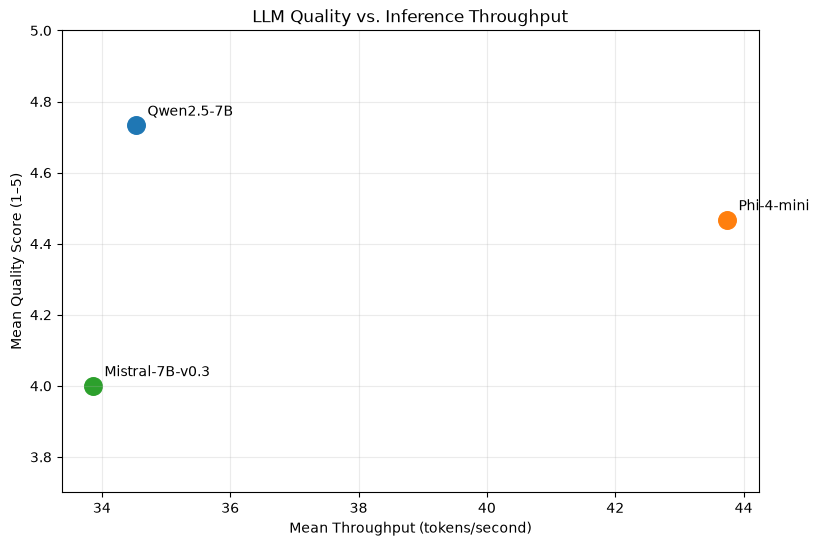

In [27]:
fig, ax = plt.subplots(figsize=(9, 6))

for _, row in final_comparison.iterrows():
    ax.scatter(
        row["Throughput (tokens/s)"],
        row["Quality Score"],
        s=160,
    )

    ax.annotate(
        row["Model"],
        (
            row["Throughput (tokens/s)"],
            row["Quality Score"],
        ),
        xytext=(8, 7),
        textcoords="offset points",
    )

ax.set_xlabel("Mean Throughput (tokens/second)")
ax.set_ylabel("Mean Quality Score (1–5)")
ax.set_title("LLM Quality vs. Inference Throughput")

ax.set_ylim(3.7, 5.0)
ax.grid(alpha=0.25)

plt.show()